# HMM Post-Processing

Random Forest + Hidden Markov Model for sleep state classification.

Adding HMM post processign since RF, XGBoost, and SVM classifies each 4 second epoch independently. 
The HMM applies Viterbi decoding to the RF probability outputs using the transition structure of sleep states so it produces more realistic sequences

Uses PyEcog's `HMM_LL` class from `hmm_pyecog.py`.
 
`hmm_pyecog.py` is not written by me (Kyri) and was already within Marco's PyEcog branch.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import os
import sys
import warnings
warnings.filterwarnings('ignore')
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    balanced_accuracy_score, cohen_kappa_score, matthews_corrcoef
)
sys.path.insert(0, os.path.abspath('..'))
from pyecog2.convert_figshare_sleep_data import readbinary_dat
from pyecog2.hmm_pyecog import HMM_LL
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 10

CLASSES=np.array(['n', 'r', 'w'])
CLASS_NAMES = {'n': 'NREM', 'r': 'REM', 'w': 'Wake'}

Leave-one-out CV with predict_proba

In [ ]:
def extract_power(power_spectra):
    bands = {
        'delta1':(0.75, 1.75),
        'delta2':(2.5, 3.5),
        'theta':(6.0, 9.0),
        'sigma':(10.0, 15.0),
        'beta_lowgamma':(18.0, 45.0)
    }
    result = {}
    for name, (lo, hi) in bands.items():
        result[name] = power_spectra[:, int(lo/0.25):int(hi/0.25)].sum(axis=1)
    return result

def load_data(dat_file):
    scores, power_spectra, eeg_var, emg_var, _ = readbinary_dat(dat_file)
    artifact_map = {'1': 'w', '2': 'n', '3':'r'}
    states = np.array([artifact_map.get(s, s) for s in scores])
    bands = extract_power(power_spectra)
    df = pd.DataFrame({'state': states, 'eeg_variance': eeg_var, 'emg_variance': emg_var, **bands})
    power_cols = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma', 'eeg_variance','emg_variance']
    df[power_cols] = np.log(df[power_cols].clip(lower=1e-30))
    df['delta2_delta1_ratio'] = df['delta2']-df['delta1']
    return df[df['state'].isin(['w','n','r'])].reset_index(drop=True)

In [5]:
dat_files = sorted(glob.glob('data/M*EXP1.dat'))
mouse_dfs = {}
for dat_file in dat_files:
    mouse_id = os.path.splitext(os.path.basename(dat_file))[0]
    mouse_dfs[mouse_id] = load_data(dat_file)
print(f'Loaded {len(mouse_dfs)} mice')

Loaded 29 mice


In [7]:
FEATURES = ['delta1', 'delta2', 'theta', 'sigma', 'beta_lowgamma', 'eeg_variance',
            'emg_variance', 'delta2_delta1_ratio']
LABEL = 'state'

In [ ]:
mouse_ids = list(mouse_dfs.keys())
rf_results = []
per_mouse = {}
all_y_true_rf = []
all_y_pred_rf = []

for test_mouse in mouse_ids:
    train_mice = [m for m in mouse_ids if m != test_mouse]
    train_df = pd.concat([mouse_dfs[m] for m in train_mice], ignore_index=True)
    test_df  = mouse_dfs[test_mouse]

    X_train = train_df[FEATURES].values
    y_train = train_df[LABEL].values
    X_test = test_df[FEATURES].values
    y_test = test_df[LABEL].values

    clf = RandomForestClassifier(
        n_estimators=100, class_weight='balanced', n_jobs=-1, random_state=7
    )
    clf.fit(X_train, y_train)

    y_pred = clf.predict(X_test)
    proba = clf.predict_proba(X_test) 

    # making sure argmax of proba matches the predictions
    assert np.all(clf.classes_[np.argmax(proba, axis=1)] == y_pred), f'argmax does not match prediction for {test_mouse}'
    bal_acc = balanced_accuracy_score(y_test, y_pred)
    rf_results.append({'mouse': test_mouse, 'balanced_accuracy': bal_acc})
    all_y_true_rf.extend(y_test)
    all_y_pred_rf.extend(y_pred)

    per_mouse[test_mouse] = {
        'y_true': y_test,
        'y_pred': y_pred,
        'proba': proba,
        'classes': clf.classes_,
        'y_train': y_train, #for transition matrix
        'train_mice': train_mice
    }
    print(f'{test_mouse}: RF balanced accuracy = {bal_acc:.3f}')

In [12]:
print(f'\nRF mean balanced accuracy: {rf_results_df["balanced_accuracy"].mean():.3f} +/- {rf_results_df["balanced_accuracy"].std():.3f}')


RF mean balanced accuracy: 0.797 +/- 0.121


In [ ]:
#cleared output so using per_mouse from memory
all_y_true_rf = []
all_y_pred_rf = []
for d in per_mouse.values():
    all_y_true_rf.extend(d['y_true'])
    all_y_pred_rf.extend(d['y_pred'])

In [17]:
kappa_rf = cohen_kappa_score(all_y_true_rf, all_y_pred_rf)
mcc_rf   = matthews_corrcoef(all_y_true_rf, all_y_pred_rf)
print(f"Cohen's kappa: {kappa_rf:.4f}  MCC: {mcc_rf:.4f}")

Cohen's kappa: 0.7921  MCC: 0.7925


Transition Matrix Estimation

In [18]:
def estimate_transition_matrix(mouse_dfs_train, classes):
    """
    Estimating transition matrix between states
    Counts transitions within each mouse only.

    Returns A where A[i, j] = P(next_state=j | current_state=i).
    """
    k = len(classes)
    idx = {c: i for i, c in enumerate(classes)}
    counts = np.ones((k, k))  # Laplace smoothing to avoid zero probabilities

    for df in mouse_dfs_train:
        states = df[LABEL].values
        for t in range(len(states) - 1):
            i = idx.get(states[t],-1)
            j = idx.get(states[t + 1],-1)
            if i >= 0 and j >= 0:
                counts[i,j] += 1

    A = counts / counts.sum(axis=1, keepdims=True)
    return A

In [22]:
# Compute transition matrix for the first fold without M10EXP1
example_mouse = mouse_ids[0]
example_train_dfs = [mouse_dfs[m] for m in mouse_ids if m != example_mouse]
classes = per_mouse[example_mouse]['classes']

A_example = estimate_transition_matrix(example_train_dfs, classes)

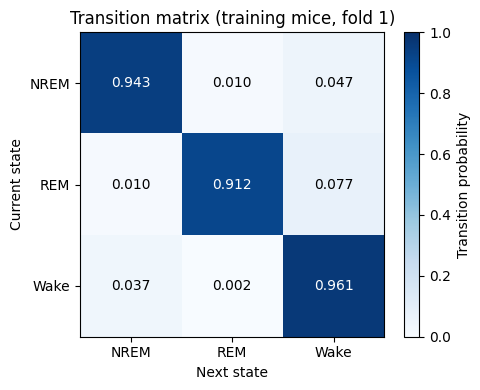

In [24]:
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(A_example, cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Transition probability')

state_labels = [CLASS_NAMES[c] for c in classes]
ax.set_xticks(range(len(classes)))
ax.set_yticks(range(len(classes)))
ax.set_xticklabels(state_labels)
ax.set_yticklabels(state_labels)
ax.set_xlabel('Next state')
ax.set_ylabel('Current state')
ax.set_title('Transition matrix (training mice, fold 1)')

for i in range(len(classes)):
    for j in range(len(classes)):
        ax.text(j, i, f'{A_example[i, j]:.3f}',
                ha='center', va='center',
                color='white' if A_example[i, j] > 0.5 else 'black', fontsize=10)

plt.tight_layout()
plt.show()

REM has the lowest self transition, makes sense since it's the 'rarest' state

Applying Viberti decoding (using HMM_LL)

In [ ]:
def apply_viterbi(proba, A, classes):
    """
    proba: (N, k) array of RF predict_proba outputs
    A:(k, k) transition matrix
    classes = length k array of class labels matching proba columns
    Returns array of decoded class labels (length n)
    """
    hmm = HMM_LL()
    hmm.A = A

    # HMM_LL expects (k, N)
    log_phi = np.log(proba.T + 1e-300)  # clipping to avoid log(0)

    ml_path, _, _ = hmm.viterbi(log_phi)
    return classes[ml_path[0]]

In [31]:
# Validating on one mouse first
test_mouse = example_mouse
d = per_mouse[test_mouse]

train_dfs = [mouse_dfs[m] for m in mouse_ids if m != test_mouse]
A = estimate_transition_matrix(train_dfs, d['classes'])

y_true  = d['y_true']
y_rf    = d['y_pred']
y_hmm   = apply_viterbi(d['proba'], A, d['classes'])

bal_rf  = balanced_accuracy_score(y_true, y_rf)
bal_hmm = balanced_accuracy_score(y_true, y_hmm)
kappa_rf  = cohen_kappa_score(y_true, y_rf)
kappa_hmm = cohen_kappa_score(y_true, y_hmm)

Viterbi (jit) 3 86400


In [39]:
print(f'Mouse: {test_mouse}')
print(f'{"Balanced accuracy:":} rf:{bal_rf:1.3f}  rf+hmm:{bal_hmm:1.3f}')
print(f"{'Cohens kappa:':} rf:{kappa_rf:1.3f}  rf+hmm:{kappa_hmm:1.3f}")

Mouse: M10EXP1
Balanced accuracy: rf:0.835  rf+hmm:0.850
Cohens kappa: rf:0.853  rf+hmm:0.876


In [40]:
print('RF only:')
print(classification_report(y_true, y_rf,
                            labels=['w','n','r'], target_names=['Wake','NREM','REM']))
print('RF + HMM:')
print(classification_report(y_true, y_hmm,
                            labels=['w','n','r'], target_names=['Wake','NREM','REM']))

RF only:
              precision    recall  f1-score   support

        Wake       0.97      0.91      0.94     43468
        NREM       0.89      0.97      0.93     37815
         REM       0.69      0.63      0.66      5117

    accuracy                           0.92     86400
   macro avg       0.85      0.84      0.84     86400
weighted avg       0.92      0.92      0.92     86400

RF + HMM:
              precision    recall  f1-score   support

        Wake       0.99      0.91      0.95     43468
        NREM       0.88      0.99      0.93     37815
         REM       0.97      0.64      0.77      5117

    accuracy                           0.93     86400
   macro avg       0.95      0.85      0.89     86400
weighted avg       0.94      0.93      0.93     86400



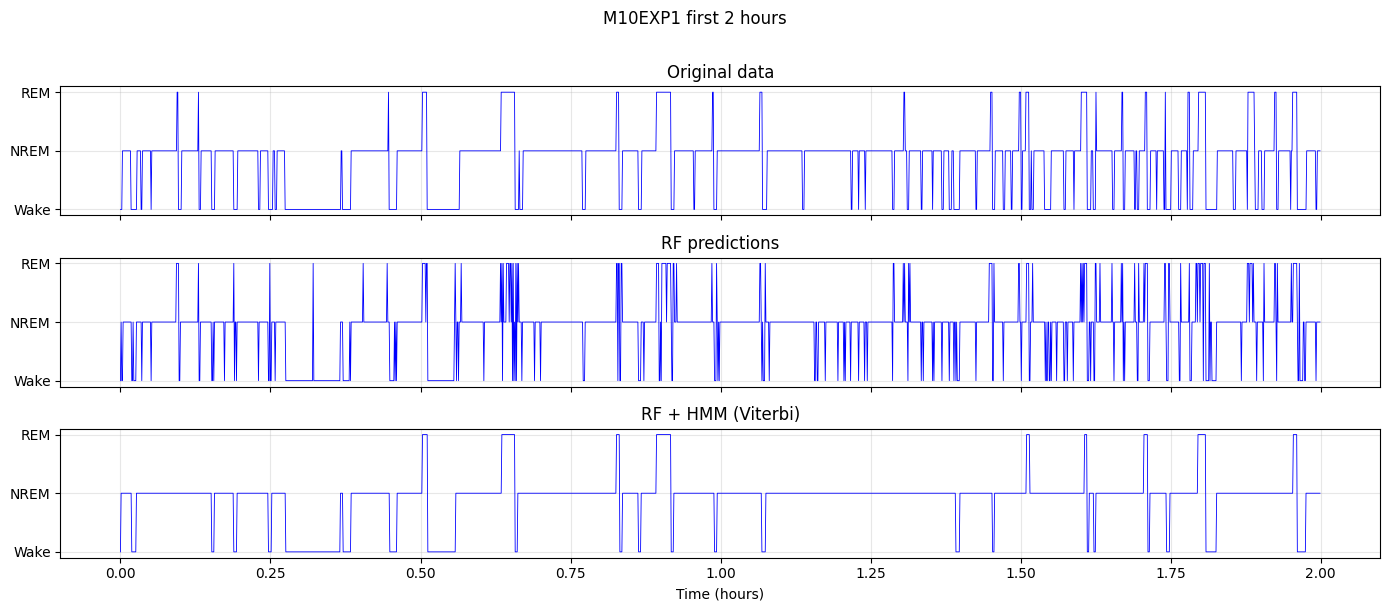

In [44]:
# 2 hour window plot for M10EXP1 comparing True values, RF and RF + HMM
# Each epoch is 4 seconds; 1 hour = 900 epochs
state_int = {'w': 0, 'n': 1, 'r': 2}
window = slice(0, 1800)

t_hours = np.arange(len(y_true)) * 4 / 3600

fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)

for ax, labels, title in zip(
    axes,
    [y_true, y_rf, y_hmm],
    ['Original data', 'RF predictions', 'RF + HMM (Viterbi)']
):
    ax.plot(t_hours[window], [state_int[s] for s in labels[window]],
            linewidth=0.6, color='blue')
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['Wake', 'NREM', 'REM'])
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time (hours)')
plt.suptitle(f'M10EXP1 first 2 hours', y=1.01)
plt.tight_layout()
plt.show()